# Virágfelismerés – Adatfeltáró elemzés (EDA)

Ebben a notebookban a virágképekből álló datasetet vizsgáljuk meg.

Célok:
- az adatok szerkezetének megértése
- kategóriák eloszlásának vizsgálata
- képméretek elemzése
- vizualizációk készítése

## CRISP‑DM – Adatmegértés

A CRISP‑DM módszertan második lépése az **adatmegértés**.

Ebben a lépésben:
- feltárjuk az adatok szerkezetét
- megvizsgáljuk az eloszlásokat
- vizualizációkat készítünk

In [1]:
import os
import tarfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Projektgyökér meghatározása helyi Jupyter és Colab futtatáshoz.
cwd = Path.cwd()
possible_roots = [
    cwd,
    cwd.parent,
    Path("/content/adatelemzesi-projekt"),
    Path("/content/drive/MyDrive/adatelemzesi-projekt"),
]

PROJECT_ROOT = None
for candidate in possible_roots:
    if (candidate / "notebooks").exists() and (candidate / "README.md").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    if cwd.name == "notebooks" and (cwd.parent / "README.md").exists():
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOKS_DIR.exists() and Path.cwd() != NOTEBOOKS_DIR:
    os.chdir(NOTEBOOKS_DIR)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = DATA_RAW_DIR / "flower_photos"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

for directory in [DATA_RAW_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Automatikus adathalmaz-letöltés, ha hiányzik (Colabban nem kell Kaggle token).
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
if not DATASET_PATH.exists():
    archive_path = DATA_RAW_DIR / "flower_photos.tgz"
    print(f"Az adathalmaz nem található itt {DATASET_PATH}. letöltés innen: {DATASET_URL}")
    urllib.request.urlretrieve(DATASET_URL, archive_path)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_RAW_DIR)
    archive_path.unlink(missing_ok=True)
    print(f"Adathalmaz kicsomagolva ide: {DATASET_PATH}")
else:
    print(f"Adathalmaz megtalálva: {DATASET_PATH}")

print(f"Projekt gyökérmappa: {PROJECT_ROOT}")


## Adathalmaz elérési útja

In [2]:
dataset_path = DATASET_PATH
dataset_path


PosixPath('../data/raw/flower_photos')

## Virág kategóriák

In [3]:
class_names = sorted([item.name for item in dataset_path.glob("*") if item.is_dir()])

hungarian_labels = {
    "daisy": "százszorszép",
    "dandelion": "pitypang",
    "roses": "rózsa",
    "sunflowers": "napraforgó",
    "tulips": "tulipán"
}

print("Virág kategóriák:")
for c in class_names:
    print(c, "→", hungarian_labels[c])

Virág kategóriák:
daisy → százszorszép
dandelion → pitypang
roses → rózsa
sunflowers → napraforgó
tulips → tulipán


## Képek száma kategóriánként

In [4]:
image_counts = {}

for flower_class in class_names:
    class_path = dataset_path / flower_class
    image_counts[flower_class] = len(list(class_path.glob("*")))

image_counts_df = pd.DataFrame({
    "kategoria_angol": list(image_counts.keys()),
    "kategoria_magyar": [hungarian_labels[name] for name in image_counts.keys()],
    "image_count": list(image_counts.values())
})
image_counts_path = TABLES_DIR / "02_image_counts.csv"
image_counts_df.to_csv(image_counts_path, index=False)
print(f"Táblázat mentve: {image_counts_path}")

image_counts_df


{'daisy': 633,
 'dandelion': 898,
 'roses': 641,
 'sunflowers': 699,
 'tulips': 799}

## Osztályeloszlás vizualizációja

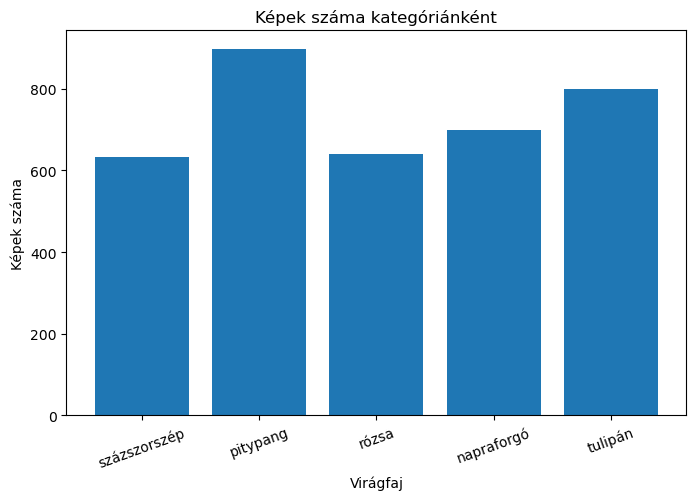

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    [hungarian_labels[name] for name in image_counts.keys()],
    image_counts.values()
)

plt.title("Képek száma kategóriánként")
plt.xlabel("Virágfaj")
plt.ylabel("Képek száma")
plt.xticks(rotation=20)
class_distribution_path = FIGURES_DIR / "02_class_distribution.png"
plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {class_distribution_path}")
plt.show()


## Mintaképek a datasetből

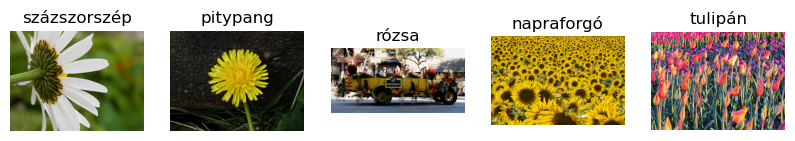

In [6]:
plt.figure(figsize=(10,10))

for i, flower_class in enumerate(class_names[:5]):
    class_path = dataset_path / flower_class
    image_path = list(class_path.glob("*"))[0]
    img = Image.open(image_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(hungarian_labels[flower_class])
    plt.axis("off")

sample_images_path = FIGURES_DIR / "02_sample_images.png"
plt.savefig(sample_images_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {sample_images_path}")
plt.show()


## Képméretek vizsgálata

In [7]:
widths = []
heights = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg",".jpeg",".png")):
            path = os.path.join(root,file)
            try:
                img = Image.open(path)
                widths.append(img.size[0])
                heights.append(img.size[1])
            except:
                pass

print("Vizsgált képek száma:", len(widths))

image_size_summary_df = pd.DataFrame([{
    "num_images": len(widths),
    "width_min": int(np.min(widths)) if widths else None,
    "width_max": int(np.max(widths)) if widths else None,
    "width_mean": float(np.mean(widths)) if widths else None,
    "height_min": int(np.min(heights)) if heights else None,
    "height_max": int(np.max(heights)) if heights else None,
    "height_mean": float(np.mean(heights)) if heights else None
}])
image_size_summary_path = TABLES_DIR / "02_image_size_summary.csv"
image_size_summary_df.to_csv(image_size_summary_path, index=False)
print(f"Táblázat mentve: {image_size_summary_path}")


Vizsgált képek száma: 3670


## Képszélességek hisztogramja

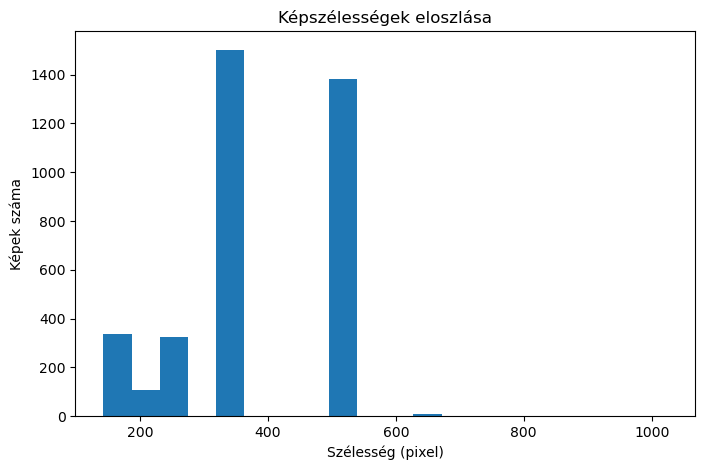

In [8]:
plt.figure(figsize=(8,5))
plt.hist(widths, bins=20)
plt.title("Képszélességek eloszlása")
plt.xlabel("Szélesség (pixel)")
plt.ylabel("Képek száma")
width_hist_path = FIGURES_DIR / "02_width_histogram.png"
plt.savefig(width_hist_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {width_hist_path}")
plt.show()


## Képmagasságok hisztogramja

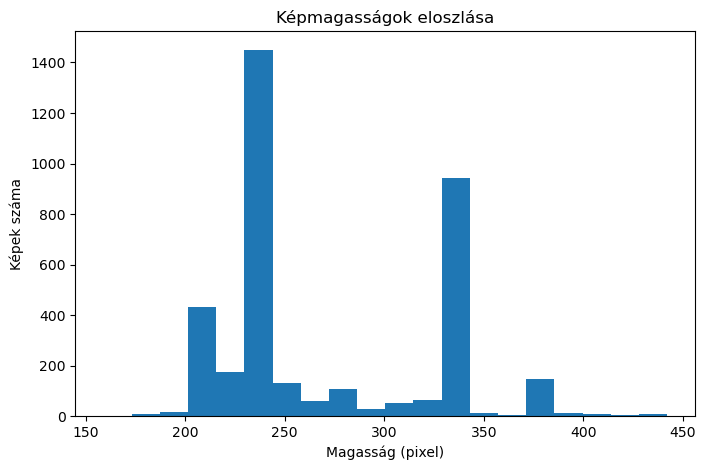

In [9]:
plt.figure(figsize=(8,5))
plt.hist(heights, bins=20)
plt.title("Képmagasságok eloszlása")
plt.xlabel("Magasság (pixel)")
plt.ylabel("Képek száma")
height_hist_path = FIGURES_DIR / "02_height_histogram.png"
plt.savefig(height_hist_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {height_hist_path}")
plt.show()


## Következtetések

- A dataset 5 különböző virágfajt tartalmaz.
- Az osztályok képszáma nem teljesen egyenletes.
- A képek mérete eltérő, ezért a modell tanításakor egységes méretre kell őket átméretezni.